# Notebook for up- and downscaling the time axis of a netcdf dataset

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import os
import dask
from dask.distributed import Client

In [2]:


def select_area(aoi, ds):
    """Helper function to select the area of interest from a dataset."""
    # Determine the dimension names for latitude and longitude
    lat_name = 'lat' if 'lat' in ds.dims else 'latitude'
    lon_name = 'lon' if 'lon' in ds.dims else 'longitude'
    
    # Select the area based on the area of interest
    area_subset = ds.sel({lon_name: slice(aoi[0], aoi[1]),
                          lat_name: slice(aoi[2], aoi[3])})
    return area_subset


In [39]:
f = "EDGAR2024_CO2_interpolated_daily_all_sectors_2020.nc"
f[-7:-3]

'2020'

In [10]:
# Rechunk explicitly
ds_daily = ds_daily.chunk({'time': 90, 'latitude': 600, 'longitude': 900})
ds_daily

<xarray.Dataset>
Dimensions:    (time: 365, latitude: 1800, longitude: 3600)
Coordinates:
  * time       (time) datetime64[ns] 2018-01-01 2018-01-02 ... 2018-12-31
  * latitude   (latitude) float64 -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * longitude  (longitude) float64 -180.0 -179.9 -179.8 ... 179.7 179.8 179.9
Data variables:
    emi_fire   (time, latitude, longitude) float64 dask.array<chunksize=(90, 600, 900), meta=np.ndarray>
Attributes:
    description:  Preprocessed CO2 fire emissions from GFAS. Units and variab...
    units:        kg(CO2) m-2 hr-1

In [26]:
# toy data to test how resample works
import numpy as np

time = pd.date_range("2000-01-01", freq="h", periods=24)

toyds = xr.Dataset({"sheep": ("time", np.arange(24)), "time": time})
toyds

<xarray.Dataset>
Dimensions:  (time: 24)
Coordinates:
  * time     (time) datetime64[ns] 2000-01-01 ... 2000-01-01T23:00:00
Data variables:
    sheep    (time) int64 0 1 2 3 4 5 6 7 8 9 ... 14 15 16 17 18 19 20 21 22 23

In [34]:
toyds3hr = toyds.resample(time="3h", closed="left", label="left").mean()
toyds3hr

<xarray.Dataset>
Dimensions:  (time: 8)
Coordinates:
  * time     (time) datetime64[ns] 2000-01-01 ... 2000-01-01T21:00:00
Data variables:
    sheep    (time) float64 1.0 4.0 7.0 10.0 13.0 16.0 19.0 22.0

# Upscale daily data to 3-hourly by repeating the values

In [4]:
client = Client(n_workers=os.cpu_count()-2, threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 6,Total memory: 30.76 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42351,Workers: 6
Dashboard: http://127.0.0.1:8787/status,Total threads: 6
Started: Just now,Total memory: 30.76 GiB
Comm: tcp://127.0.0.1:41631,Total threads: 1
Dashboard: http://127.0.0.1:45027/status,Memory: 5.13 GiB
Nanny: tcp://127.0.0.1:38575,


In [47]:
client.close()

In [3]:
ds = xr.open_dataset("/home/pietaril/Documents/data/EDGAR2024_CO2/interp_daily/EDGAR2024_CO2_interpolated_daily_all_sectors_2008.nc")
ds

<xarray.Dataset>
Dimensions:    (time: 366, latitude: 1800, longitude: 3600)
Coordinates:
  * latitude   (latitude) float64 -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * longitude  (longitude) float64 -179.9 -179.8 -179.8 ... 179.8 179.8 179.9
  * time       (time) datetime64[ns] 2008-01-01 2008-01-02 ... 2008-12-31
Data variables:
    emi_anth   (time, latitude, longitude) float64 ...
Attributes:
    description:  Sum of gridded EDGAR_2024_GHG CO2 fluxes from all sectors, ...
    units:        kg m-2 hr-1

In [6]:
from tqdm import tqdm

#DATAPATH = "/media/pietaril/Elements/CO2_CIF_priors/original_timeresol_and_domain/GFAS/" 
DATAPATH = "/home/pietaril/Documents/data/EDGAR2024_CO2/global_0.1x0.1/interp_daily/"

aoi = [-25, 45, 24, 83] #extend EU domain 10 degrees each side
if "EDGAR" in DATAPATH:
    varname = "emi_anth"
    description = "Sum of gridded EDGAR_2024_GHG CO2 fluxes from all sectors, interpolated first to \n daily time resolution and then upscaled to 3-hourly resolution by repeating the daily values."
    OUTPATH = "/home/pietaril/Documents/data/EDGAR2024_CO2/Europe_3hourly_0.1x0.1/"#"/media/pietaril/Elements/CO2_CIF_priors/Europe_3-hourly/EDGAR_2024/"
    outname = "EDGAR_2024_CO2_flux_3hourly_eur"
elif "GFAS" in DATAPATH:
    varname = "emi_fire"
    description = "GFAS CO2 emissions upscaled to 3-hourly resolution by repeating the daily values."
    OUTPATH = "/media/pietaril/Elements/CO2_CIF_priors/Europe_3-hourly/GFAS/"
    outname = "GFAS_CO2_flux_3hourly_eur"
else:
    raise ValueError("Wrong path")

fnames = [os.path.join(DATAPATH, f) for f in os.listdir(DATAPATH)]
for f in tqdm(fnames):
    year = f[-7:-3]
    ds = xr.open_dataset(f, chunks={'latitude':110})
    eur = select_area(aoi, ds)
    #ds.close()
    with dask.config.set({"array.slicing.split_large_chunks": False}):
       
        #Add a dummy time step with NaNs (will be ignored by ffill)
        hr3 = (eur.reindex(time=pd.date_range(eur.time.values[0], eur.time.values[-1] + np.timedelta64(1, "D"), freq="D"))
               .resample(time="3h", closed="left", label="left").ffill(tolerance="1D"))


        #cut out the extra timestamp that the previous commands created
        hr3 = hr3.isel(time=slice(None, -1))

        hr3.attrs = {}
        hr3.attrs.update({"description": description,
                              "units": "kg m-2 hr-1"})
        
        hr3.to_netcdf(os.path.join(OUTPATH,f"{outname}_{year}.nc"), encoding={'time':{'units': "days since 1900-01-01"}, varname: {'dtype': 'float64', 'zlib': True, 'shuffle':True, 'complevel': 5}})
        print(year)

  6%|▋         | 1/16 [02:17<34:27, 137.81s/it]

2014


 12%|█▎        | 2/16 [04:42<33:05, 141.85s/it]

2016


 19%|█▉        | 3/16 [07:05<30:52, 142.52s/it]

...

2013


 94%|█████████▍| 15/16 [33:54<02:10, 130.69s/it]

2012


100%|██████████| 16/16 [36:02<00:00, 135.18s/it]

2022


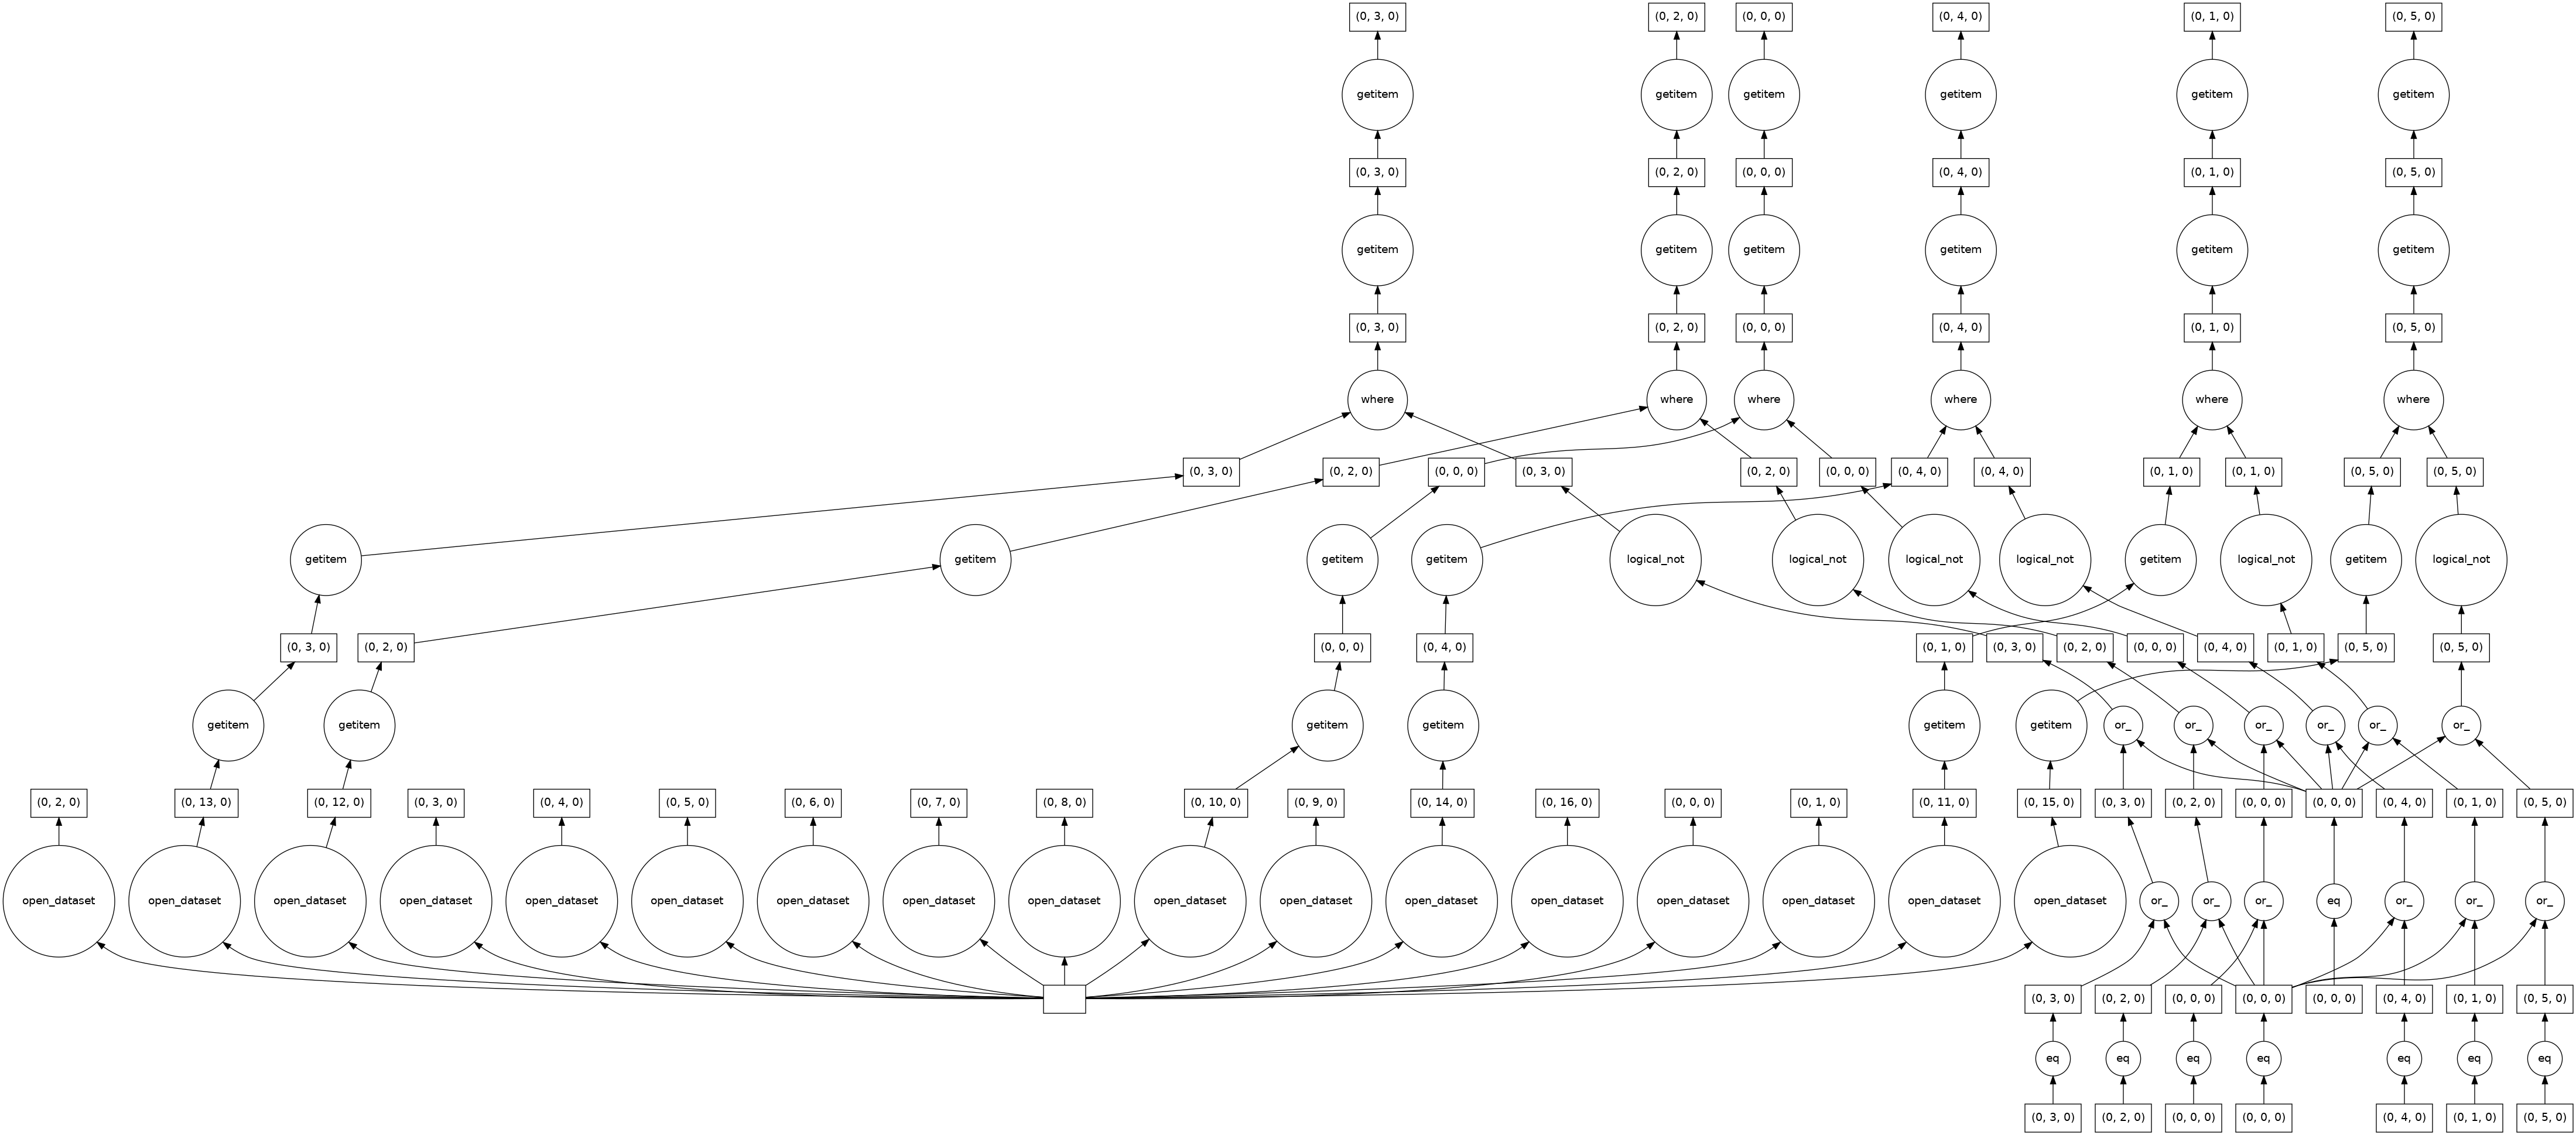

In [45]:
dask.visualize(hr3)

In [50]:
OUTPATH = "/media/pietaril/Elements/CO2_CIF_priors/Europe_3-hourly/GFAS/"
fnames = [os.path.join(OUTPATH, f) for f in os.listdir(OUTPATH)]
ds = xr.open_dataset(fnames[7])
ds

<xarray.Dataset>
Dimensions:    (time: 2928, latitude: 590, longitude: 700)
Coordinates:
  * time       (time) datetime64[ns] 2020-01-01 ... 2020-12-31T21:00:00
  * latitude   (latitude) float64 24.05 24.15 24.25 24.35 ... 82.75 82.85 82.95
  * longitude  (longitude) float64 -24.95 -24.85 -24.75 ... 44.75 44.85 44.95
Data variables:
    emi_fire   (time, latitude, longitude) float64 ...
Attributes:
    description:  GFAS CO2 emissions upscaled to 3-hourly resolution by repea...
    units:        kg m-2 hr-1

In [21]:
hr3.compute()

<xarray.Dataset>
Dimensions:    (time: 2913, latitude: 580, longitude: 700)
Coordinates:
  * time       (time) datetime64[ns] 2018-01-01 ... 2018-12-31
  * latitude   (latitude) float64 25.05 25.15 25.25 25.35 ... 82.75 82.85 82.95
  * longitude  (longitude) float64 -24.95 -24.85 -24.75 ... 44.75 44.85 44.95
Data variables:
    emi_fire   (time, latitude, longitude) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    description:  Preprocessed CO2 fire emissions from GFAS. Units and variab...
    units:        kg(CO2) m-2 hr-1

# Examine the upscaled file

In [4]:
ds1core=xr.open_dataset("/home/pietaril/Documents/data/GFAS/GFAS_CO2_emi_preprocessed/upscaled_3hrly/GFAS_CO2_3hourly_2013.nc", chunks = 'auto')
ds1core

,Array,Chunk
Bytes,140.64 GiB,127.87 MiB
Shape,"(2913, 1800, 3600)","(280, 173, 346)"
Count,2 Graph Layers,1331 Chunks
Type,float64,numpy.ndarray


In [6]:
dsncores = xr.open_dataset("/home/pietaril/Documents/data/GFAS/GFAS_CO2_emi_preprocessed/upscaled_3hrly/GFAS_CO2_3hourly_2016.nc", chunks = 'auto')
dsncores

,Array,Chunk
Bytes,141.03 GiB,127.13 MiB
Shape,"(2921, 1800, 3600)","(280, 172, 346)"
Count,2 Graph Layers,1331 Chunks
Type,float64,numpy.ndarray


In [27]:
ds.emi_fire.encoding

{'zlib': True,
 'szip': False,
 'zstd': False,
 'bzip2': False,
 'blosc': False,
 'shuffle': True,
 'complevel': 5,
 'fletcher32': False,
 'contiguous': False,
 'chunksizes': (139, 86, 172),
 'source': '/home/pietaril/Documents/data/GFAS/GFAS_CO2_emi_preprocessed/upscaled_3hrly/GFAS_CO2_3hourly_2013.nc',
 'original_shape': (2913, 1800, 3600),
 'dtype': dtype('float64'),
 '_FillValue': nan}

# Downscale hourly data to 3-hourly

In [68]:
client = Client(n_workers=os.cpu_count()-2, threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 6,Total memory: 30.76 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34107,Workers: 6
Dashboard: http://127.0.0.1:8787/status,Total threads: 6
Started: Just now,Total memory: 30.76 GiB
Comm: tcp://127.0.0.1:36039,Total threads: 1
Dashboard: http://127.0.0.1:43679/status,Memory: 5.13 GiB
Nanny: tcp://127.0.0.1:45867,


In [73]:
client.close()

2025-06-11 17:03:15,230 - distributed.core - ERROR - 
Traceback (most recent call last):
  File "/home/pietaril/.local/lib/python3.10/site-packages/distributed/utils.py", line 742, in wrapper
    return await func(*args, **kwargs)
  File "/home/pietaril/.local/lib/python3.10/site-packages/distributed/lock.py", line 49, in acquire
    await future
  File "/home/pietaril/miniconda3/envs/matrix/lib/python3.10/asyncio/locks.py", line 214, in wait
    await fut
asyncio.exceptions.CancelledError
2025-06-11 17:03:15,233 - distributed.core - ERROR - 
Traceback (most recent call last):
  File "/home/pietaril/.local/lib/python3.10/site-packages/distributed/lock.py", line 49, in acquire
    await future
  File "/home/pietaril/miniconda3/envs/matrix/lib/python3.10/asyncio/locks.py", line 214, in wait
    await fut
asyncio.exceptions.CancelledError

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/pietaril/.local/lib/python3.10/si

In [71]:
DATAPATH = "/media/pietaril/Elements/CO2_CIF_priors/original_timeresol_and_domain/JSBACH_202503/"
OUTPATH = "/media/pietaril/Elements/CO2_CIF_priors/Europe_3-hourly/JSBACH_202503"
varname = "flux_bio"
description = "JSBACH_202503 CO2 fluxes for Europe, downsampled to 3-hourly time resolution"
outname = "JSBACH_202503_CO2_flx_3hourly"


fnames = [os.path.join(DATAPATH, f) for f in os.listdir(DATAPATH)]
for f in tqdm(fnames):
    print(f)
    year = f[-7:-3]
    ds = xr.open_dataset(f, chunks={"latitude":80, "longitude":80 })
    
    jsb = ds.assign_coords(time = ds.time.dt.floor("h"))
    ds.close()
    jsb = jsb.sortby("time")
    hr3 = jsb[varname].resample(time="3h", closed="left", label="left").mean(skipna=True)

    hr3.attrs = {}
    hr3.attrs.update({"description": description,
                             "units": "kg m-2 hr-1"})
        
    hr3.to_netcdf(os.path.join(OUTPATH,f"{outname}_{year}.nc"), encoding={'time':{'units': "days since 1900-01-01"}, varname: {'dtype': 'float64', 'zlib': True, 'shuffle':True, 'complevel': 5}})


  0%|          | 0/15 [00:00<?, ?it/s]

/media/pietaril/Elements/CO2_CIF_priors/original_timeresol_and_domain/JSBACH_202503/JSBACH_202503_CO2_prior_2009.nc


  7%|▋         | 1/15 [04:51<1:07:54, 291.06s/it]

/media/pietaril/Elements/CO2_CIF_priors/original_timeresol_and_domain/JSBACH_202503/JSBACH_202503_CO2_prior_2010.nc


 13%|█▎        | 2/15 [10:01<1:05:34, 302.68s/it]

...

 87%|████████▋ | 13/15 [1:09:31<10:47, 323.71s/it]

/media/pietaril/Elements/CO2_CIF_priors/original_timeresol_and_domain/JSBACH_202503/JSBACH_202503_CO2_prior_2022.nc


 93%|█████████▎| 14/15 [1:14:51<05:22, 322.53s/it]

/media/pietaril/Elements/CO2_CIF_priors/original_timeresol_and_domain/JSBACH_202503/JSBACH_202503_CO2_prior_2023.nc


100%|██████████| 15/15 [1:20:13<00:00, 320.91s/it]


In [5]:
OUTPATH = "/media/pietaril/Elements/CO2_CIF_priors/Europe_3-hourly/GFAS/"
outfiles = [os.path.join(OUTPATH, f) for f in os.listdir(OUTPATH)]
ds = xr.open_dataset(outfiles[0])
flx = ds.emi_fire
flx

<xarray.DataArray 'emi_fire' (time: 2920, latitude: 590, longitude: 700)>
[1205960000 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 2013-01-01 ... 2013-12-31T21:00:00
  * latitude   (latitude) float64 24.05 24.15 24.25 24.35 ... 82.75 82.85 82.95
  * longitude  (longitude) float64 -24.95 -24.85 -24.75 ... 44.75 44.85 44.95
Attributes:
    units:    kg(CO2) m-2 hr-1

In [12]:
flx[1497,100,200]

<xarray.DataArray 'emi_fire' ()>
array(nan)
Coordinates:
    time       datetime64[ns] 2013-07-07T03:00:00
    latitude   float64 34.05
    longitude  float64 -4.95
Attributes:
    units:    kg(CO2) m-2 hr-1

In [53]:
ds[varname].time.dt.floor("h")

<xarray.DataArray 'floor' (time: 8760)>
array(['2009-01-01T00:00:00.000000000', '2009-01-01T01:00:00.000000000',
       '2009-01-01T02:00:00.000000000', ...,
       '2009-12-31T21:00:00.000000000', '2009-12-31T22:00:00.000000000',
       '2009-12-31T23:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2009-01-01T00:39:59.999999488 ... 2009-12-...

# JSBACH files have irregular time axis - need to regularize


In [9]:
corfile = xr.open_dataset("/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/jsbach.nc")
corfile


/home/pietaril/.local/lib/python3.10/site-packages/xarray/coding/times.py:150: SerializationWarning: Ambiguous reference date string: 1-1-1. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/home/pietaril/.local/lib/python3.10/site-packages/xarray/coding/times.py:688: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/pietaril/.local/lib/python3.10/site-packages/xarray/core/indexing.py:524: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  retu

<xarray.Dataset>
Dimensions:               (lon: 560, lat: 304, ntiles: 12, time: 12, soillev: 11)
Coordinates:
  * lon                   (lon) float32 -24.94 -24.81 -24.69 ... 44.81 44.94
  * lat                   (lat) float32 35.06 35.19 35.31 ... 72.69 72.81 72.94
  * ntiles                (ntiles) float64 1.0 2.0 3.0 4.0 ... 10.0 11.0 12.0
  * soillev               (soillev) float64 0.065 0.182 0.3926 ... 28.93 52.14
  * time                  (time) object 0001-01-31 00:00:00 ... 0001-12-31 00...
Data variables: (12/37)
    soil_porosity         (lat, lon) float64 ...
    soil_field_cap        (lat, lon) float64 ...
    wilting_point         (lat, lon) float64 ...
    moisture_pot          (lat, lon) float64 ...
    hyd_cond_sat          (lat, lon) float64 ...
    bclapp                (lat, lon) float64 ...
    ...                    ...
    cover_fract           (ntiles, lat, lon) float32 ...
    lai_clim              (time, lat, lon) float64 ...
    layer_moist           (soillev, lat, lon) float64 ...
    soil_layer_depth      (soillev) float64 ...
    surf_temp             (time, lat, lon) float64 ...
    veg_fract             (time, lat, lon) float64 ...
Attributes: (12/15)
    CDI:                          Climate Data Interface version 2.4.0 (https...
    Conventions:                  CF-1.0
    title:                        initial surface data for JSBACH
    nlct:                         22
    CDO:                          Climate Data Operators version 2.4.0 (https...
    NCO:                          netCDF Operators version 5.2.1 (Homepage = ...
    ...                           ...
    refyear_for_cover_types:      1850
    refyear_for_cover_fractions:  1850
    spherical_truncation:         T63
    configuration:                T63GR15 12tiles
    references:                   Hagemann, S. (2002): An improved land surfa...
    history_of_appended_files:    Mon Jan 27 14:26:24 2025: Appended file glo...

In [10]:
ocn = xr.open_dataset("/home/pietaril/Documents/data/CTE_ocean_fluxes/processed/highres_kg_m-2_hr-1/CTE_ocn_CO2_prior_2020.nc", chunks = 'auto')
ocn

<xarray.Dataset>
Dimensions:    (time: 8784, latitude: 390, longitude: 500)
Coordinates:
  * time       (time) datetime64[ns] 2020-01-01 ... 2020-12-31T23:00:00
  * latitude   (latitude) float64 33.05 33.15 33.25 33.35 ... 71.75 71.85 71.95
  * longitude  (longitude) float64 -14.95 -14.85 -14.75 ... 34.75 34.85 34.95
Data variables:
    emi_ocn    (time, latitude, longitude) float64 dask.array<chunksize=(1904, 83, 106), meta=np.ndarray>
Attributes:
    description:  Ocean CO2 fluxes from CTE-HR interpolated to resolution 0.1...
    units:        kg m-2 hr-1

In [ ]:


ocn3hr = ocn.emi_ocn.resample(time="3h", closed="left", label="left").mean(skipna=True)
ocn3hr.attrs = {}
ocn3hr.attrs.update({"description": "Ocean CO2 fluxes from CTE-HR interpolated to resolution 0.1 x 0.1 and downsampled to 3-hourly resolution",
                            "units": "kg m-2 hr-1"})
#ocn3hr.to_netcdf("testocn.nc", encoding={'time':{'units': "days since 1900-01-01"}, "emi_ocn": {'dtype': 'float64', 'zlib': True, 'shuffle':True, 'complevel': 5}})

In [59]:
ds = xr.open_dataset("/home/pietaril/Documents/MI-AIM/python/testocn.nc", chunks ="auto")
ds.emi_ocn.encoding

{'zlib': True,
 'szip': False,
 'zstd': False,
 'bzip2': False,
 'blosc': False,
 'shuffle': True,
 'complevel': 5,
 'fletcher32': False,
 'contiguous': False,
 'chunksizes': (419, 56, 72),
 'source': '/home/pietaril/Documents/MI-AIM/python/testocn.nc',
 'original_shape': (2928, 390, 500),
 'dtype': dtype('float64'),
 '_FillValue': nan}